In [1]:
%load_ext cuml.accel
%run /mnt/d/Users/Admin/Projects/dso/SAR_ML/notebooks/SSR/SSRtransforms_preloaded.py
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models

In [2]:
# workspace = "/workspace/alvin/SAR_ML"
workspace = "/mnt/d/Users/Admin/Projects/dso/SAR_ML"
data_workspace = os.path.join(workspace, "data/SAMPLE")

In [3]:
with open(os.path.join(workspace, "weights/SSR/SAMPLE_synth_gmm_cache.pkl"), "rb") as f:
    gmm_cache = pickle.load(f)

In [4]:
no_aug_synth_ds = synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

# No augmentation

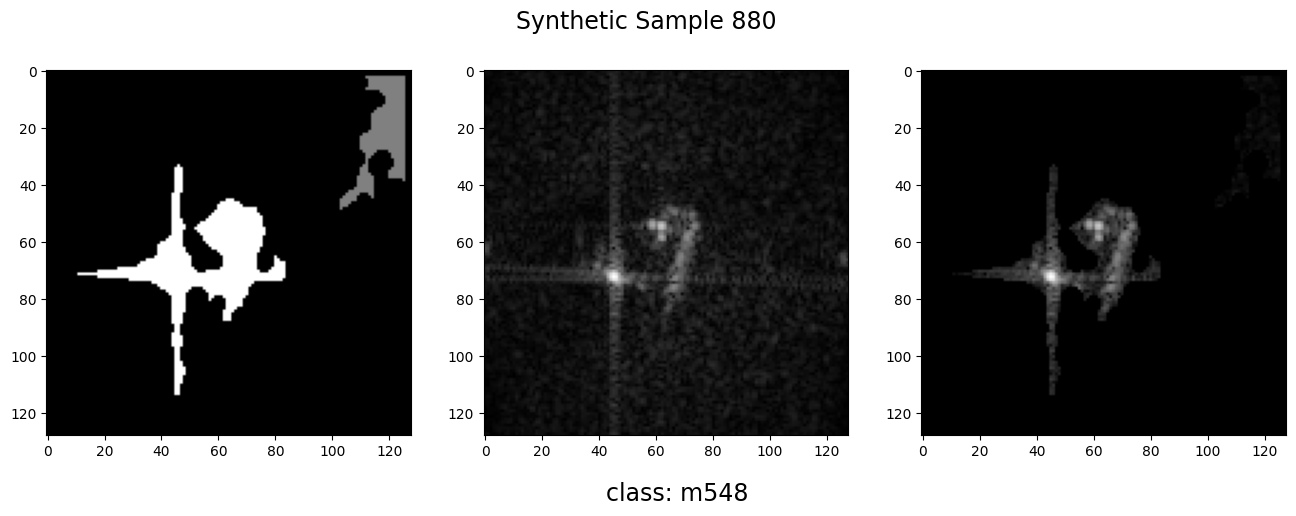

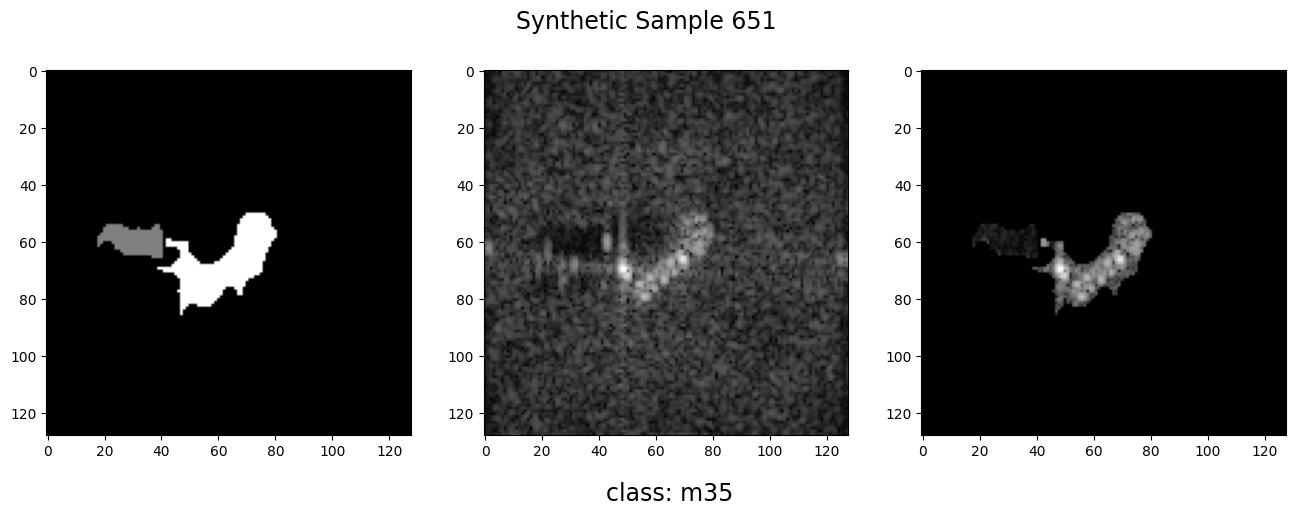

In [5]:
for idx in [880, 651]:
    img = no_aug_synth_ds[idx][0][0]
    t, s, c = choi_segmentation(img)
    
    fig = plt.figure(figsize = (16, 5))
    ax0 = fig.add_subplot(1, 3, 1)
    ax0.imshow(t*2 + s*1, cmap = "gray")
    ax1 = fig.add_subplot(1, 3, 2)
    ax1.imshow(img, cmap = "gray")
    ax2 = fig.add_subplot(1, 3, 3)
    ax2.imshow(img * (torch.tensor(t) + torch.tensor(s)), cmap = "gray", vmin = 0, vmax = 1)
    
    fig.suptitle(f"Synthetic Sample {idx}", size = 17)
    plt.figtext(0.475, -0.0025, f"class: {no_aug_synth_ds.classes[no_aug_synth_ds[idx][1]]}", size = 17)
    plt.show()

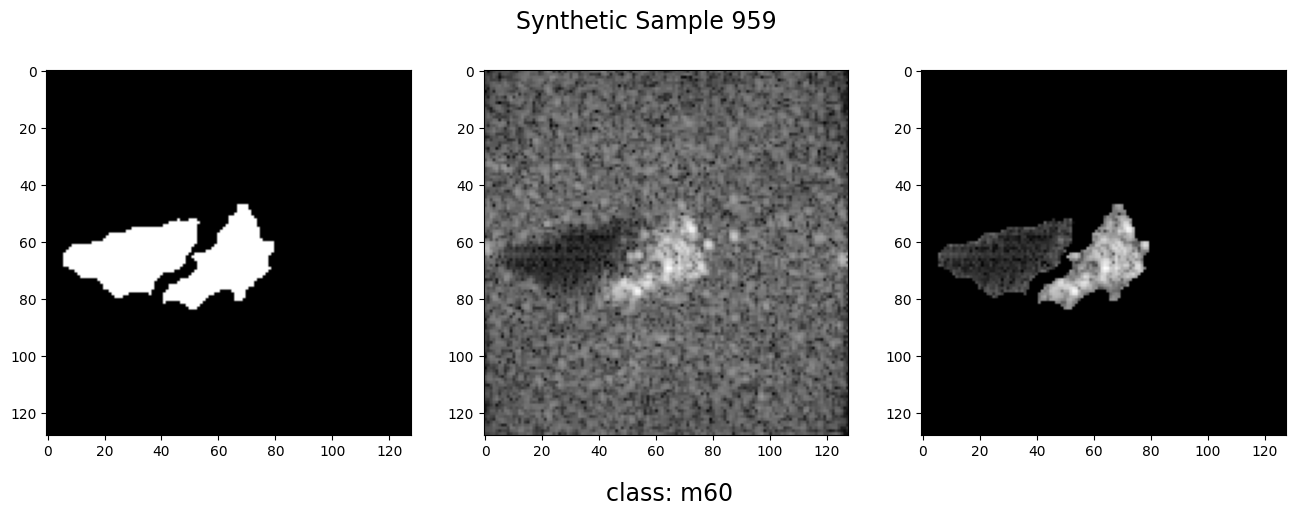

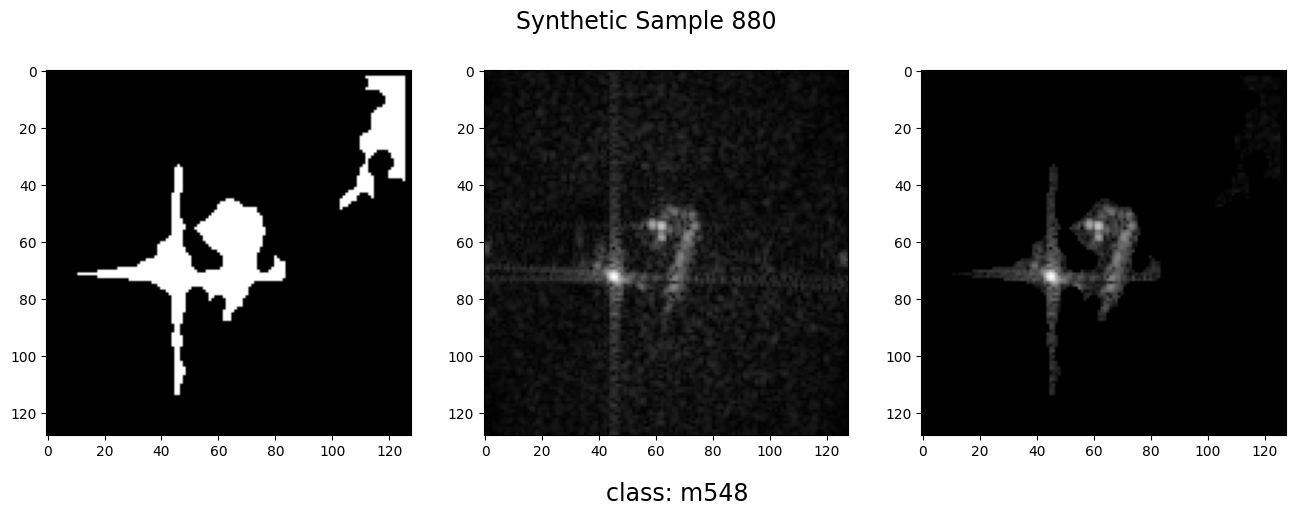

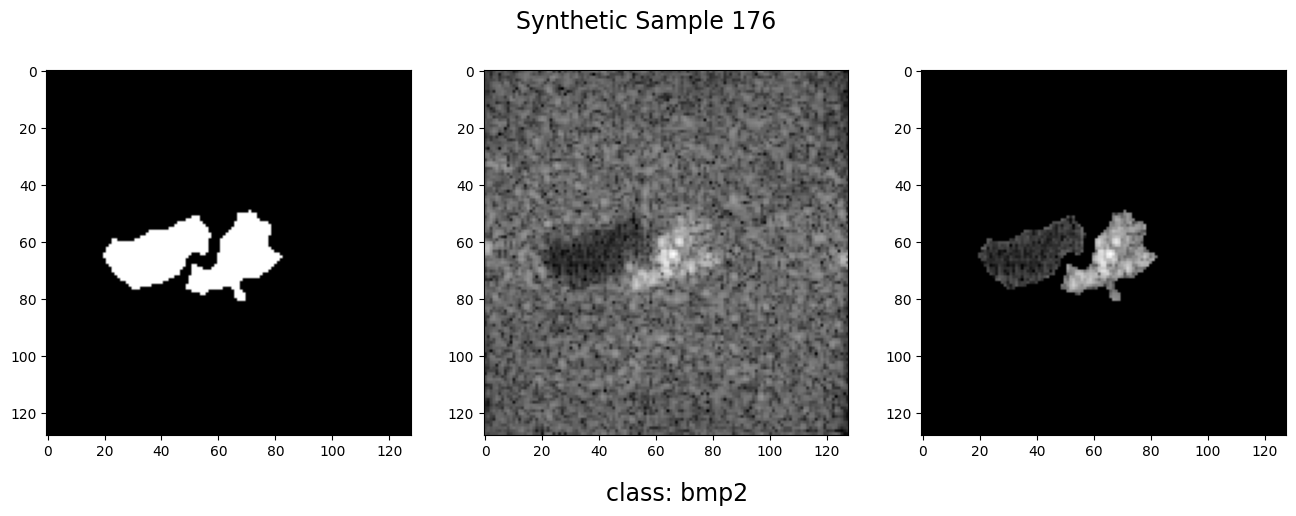

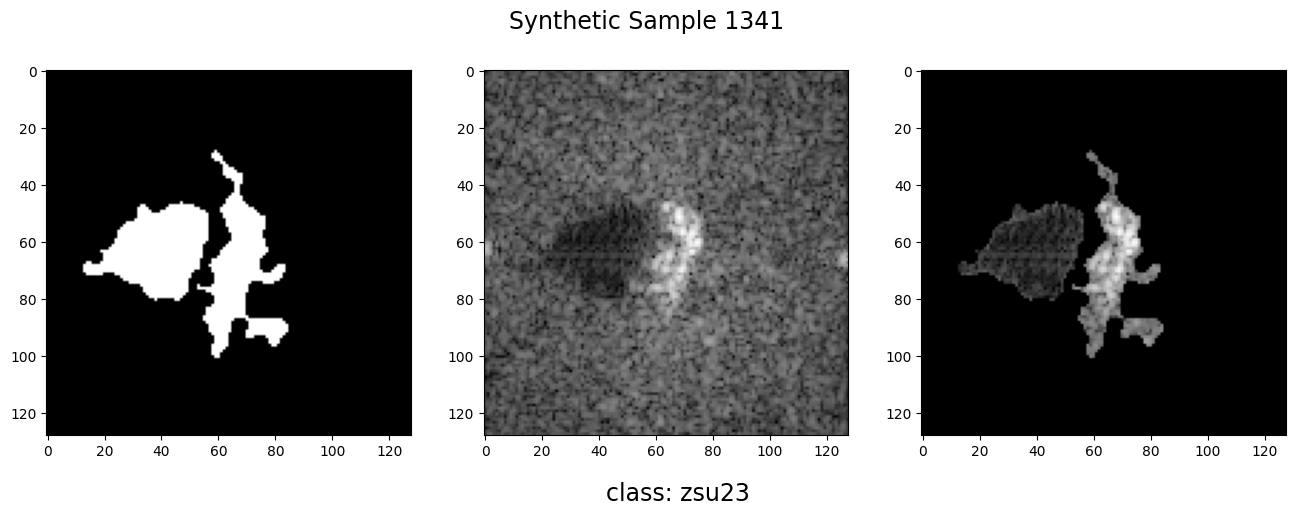

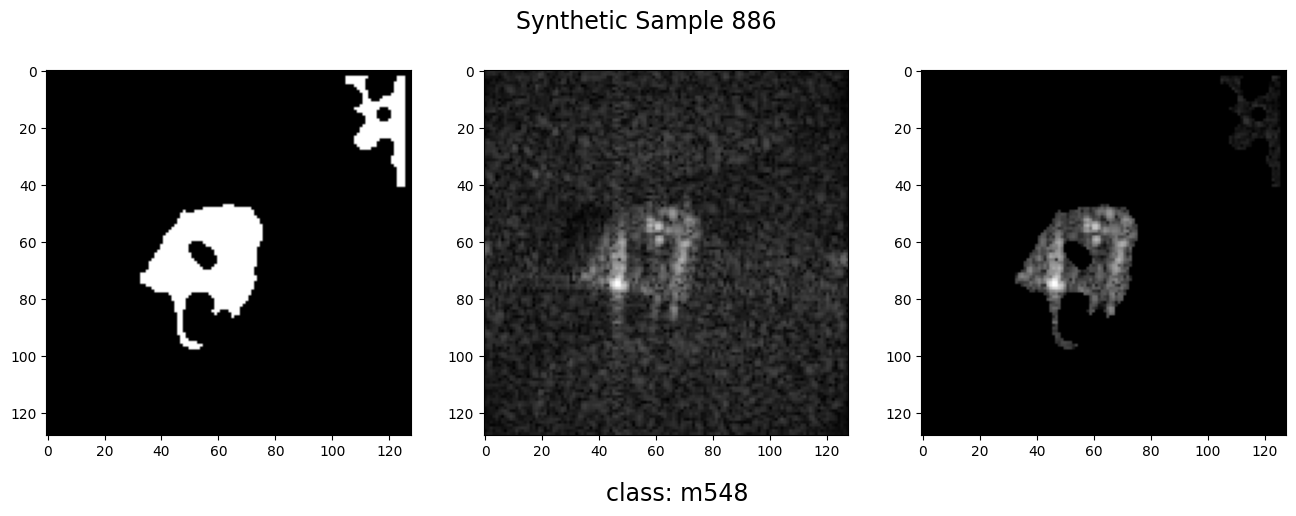

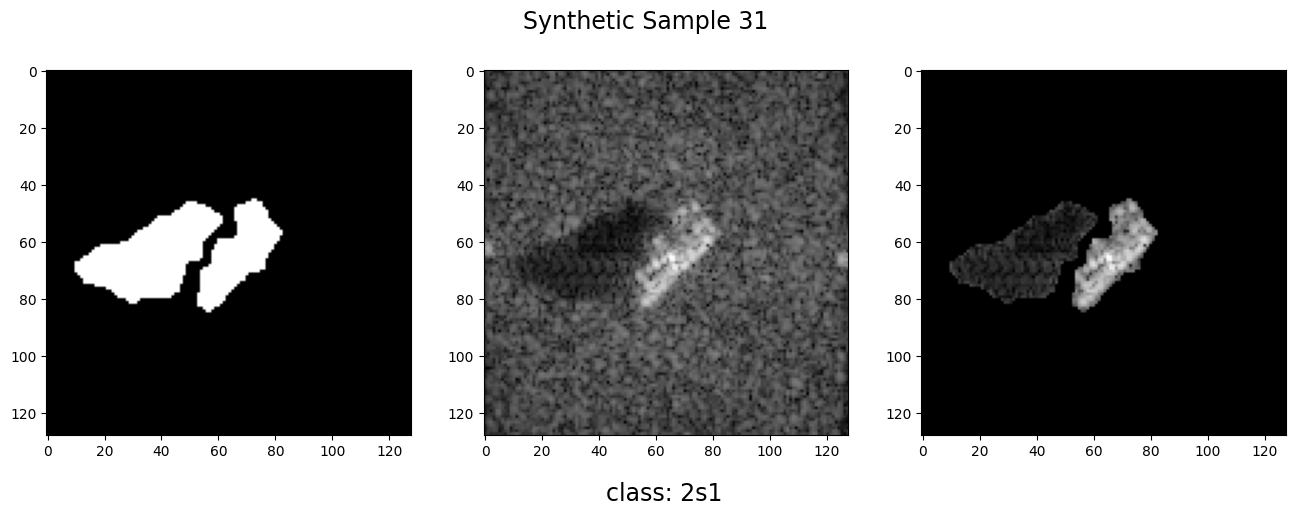

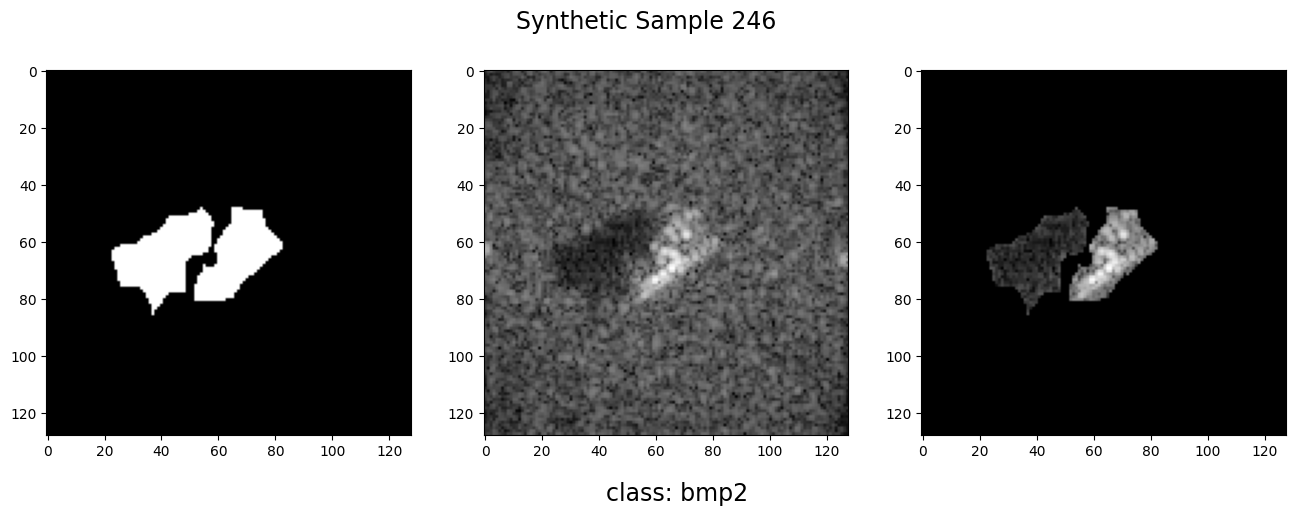

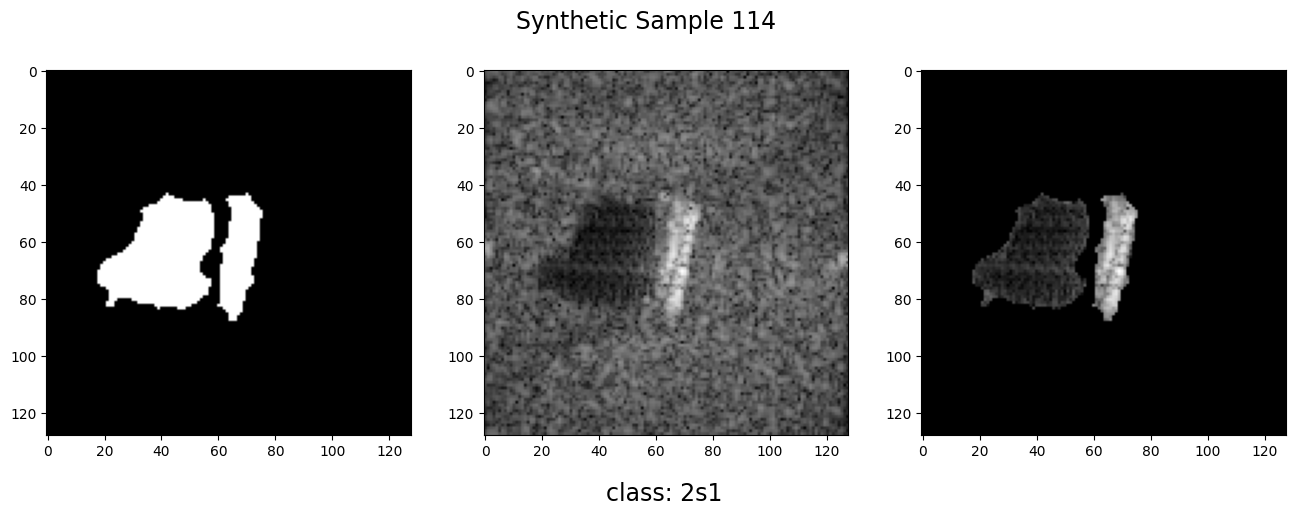

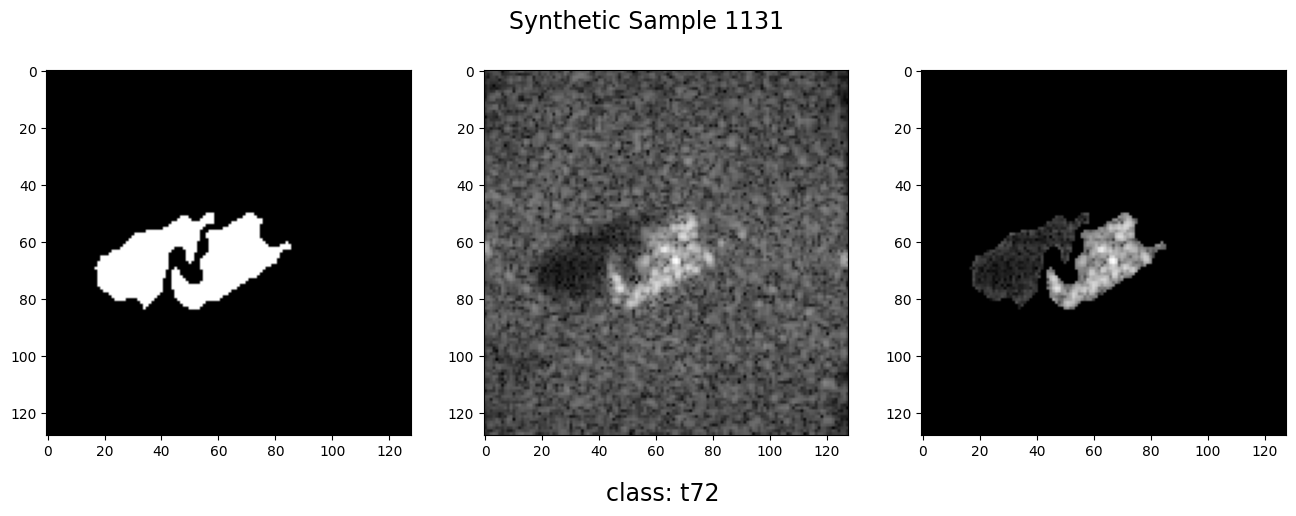

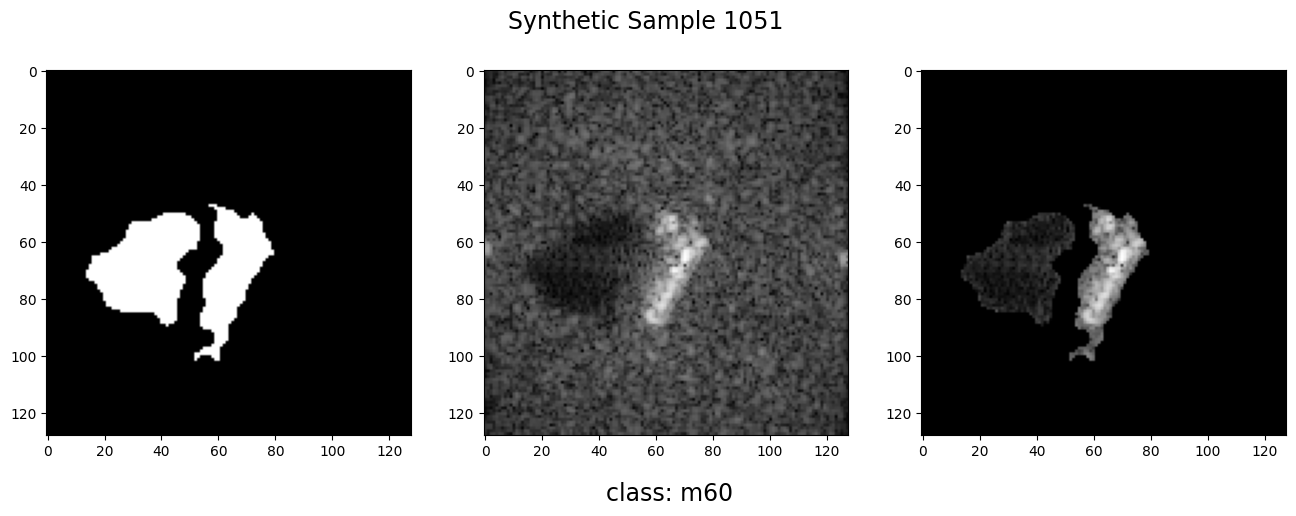

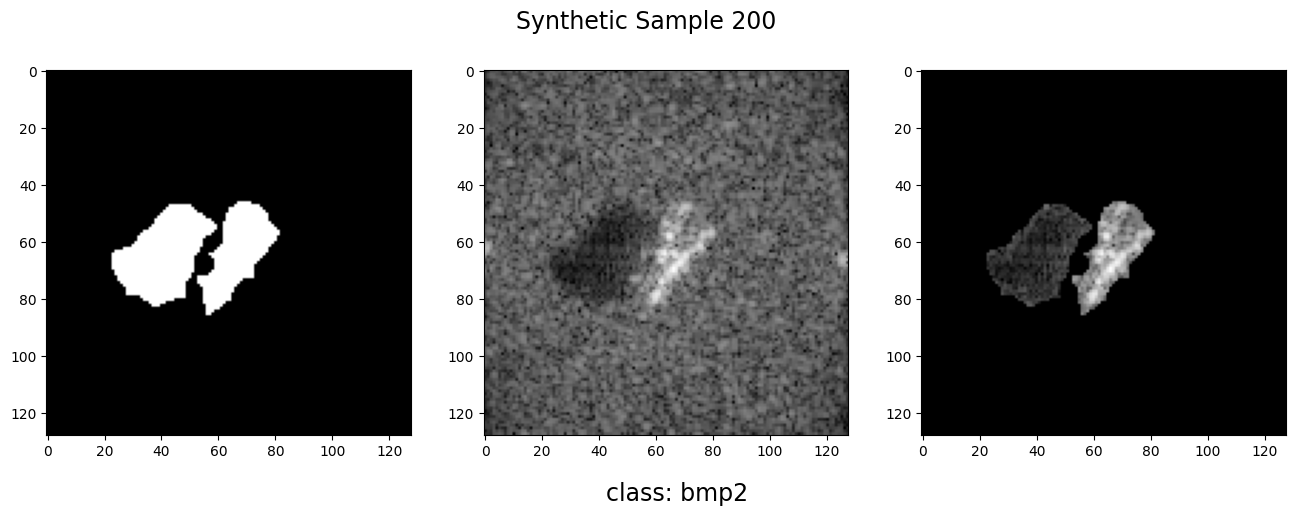

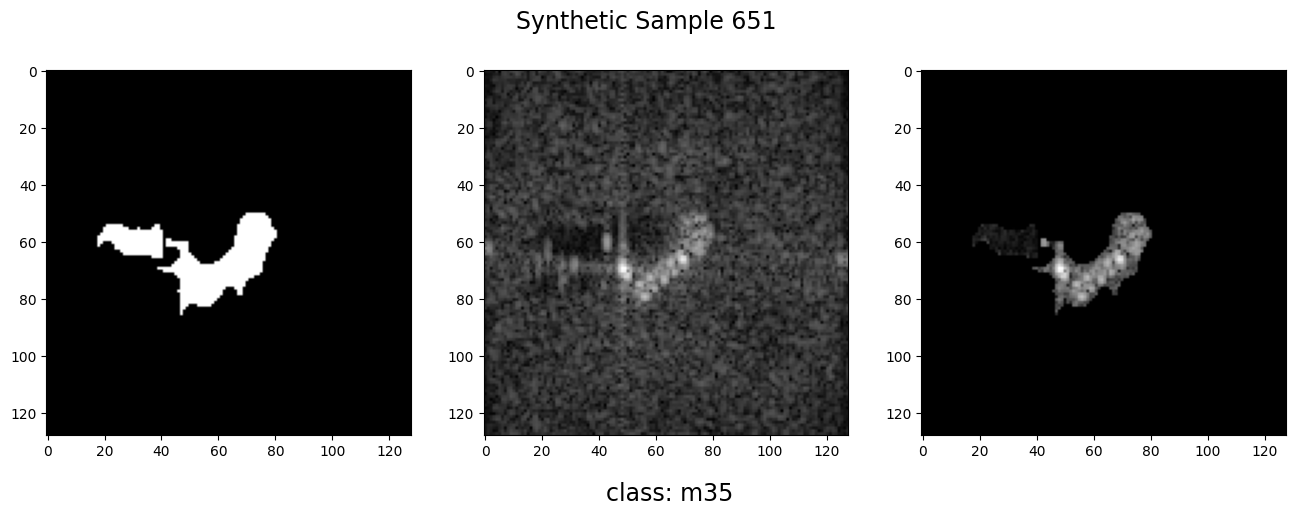

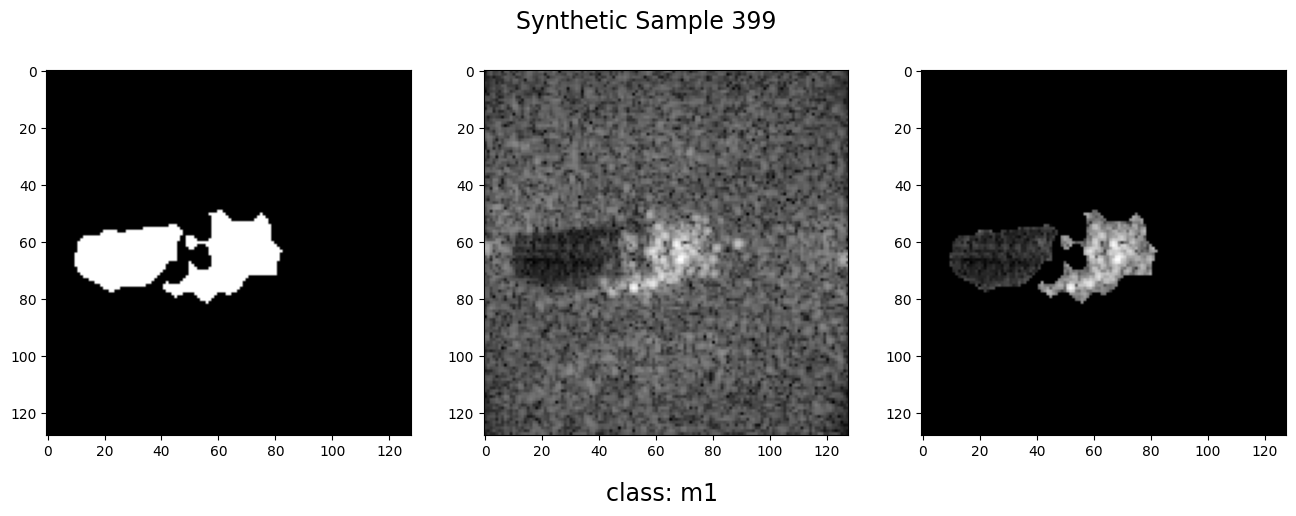

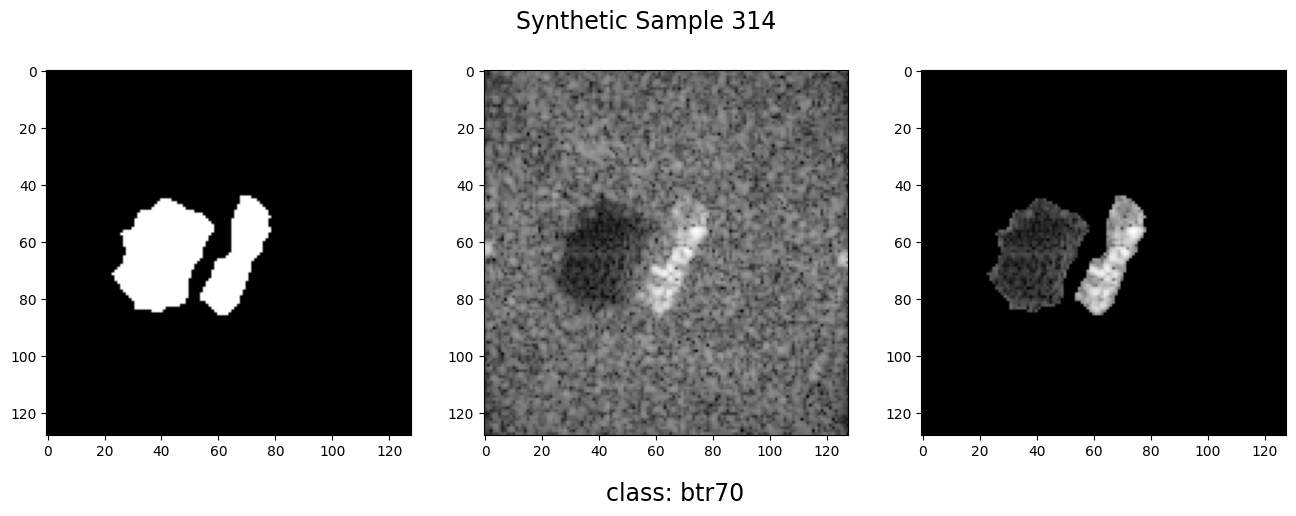

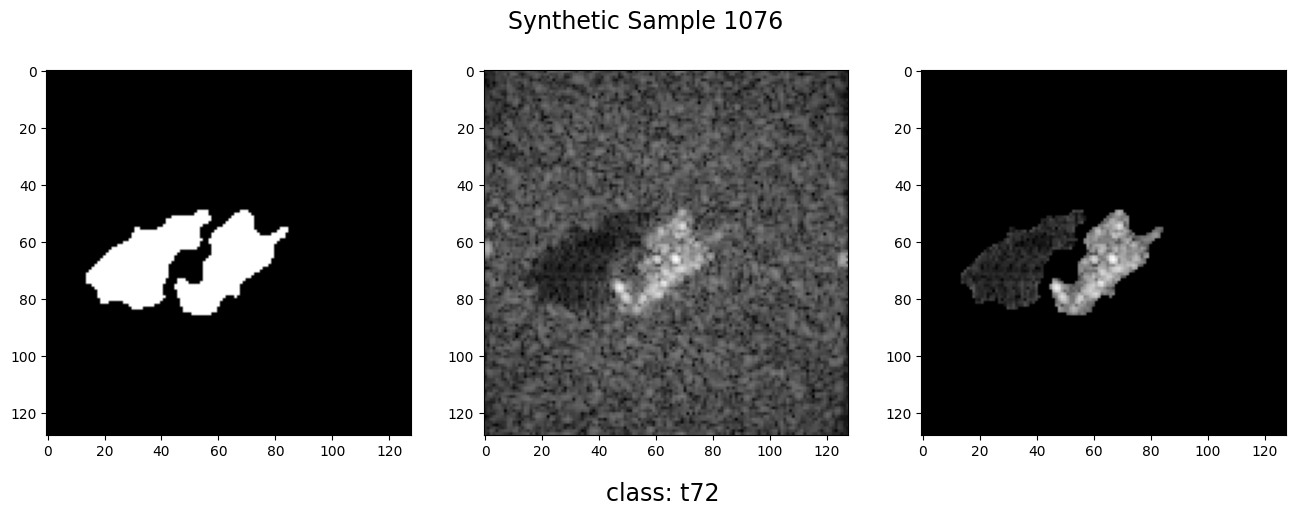

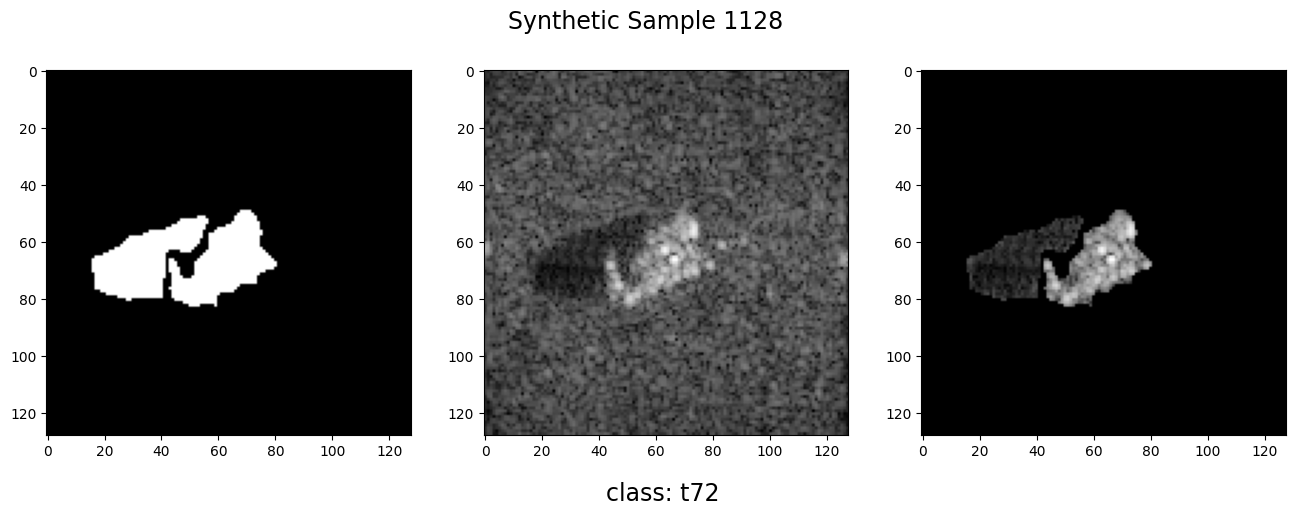

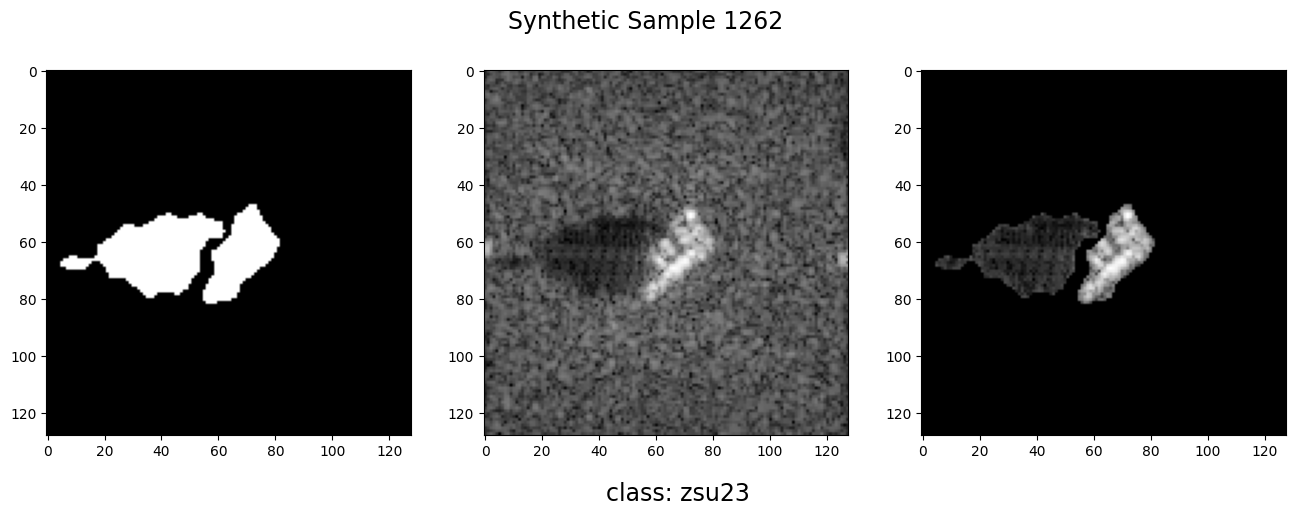

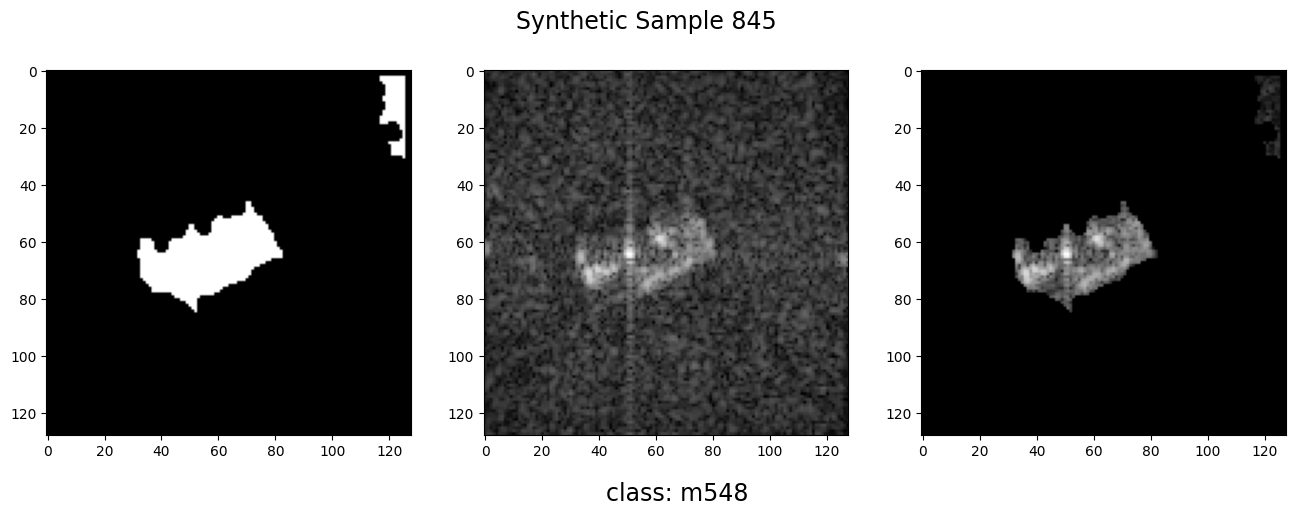

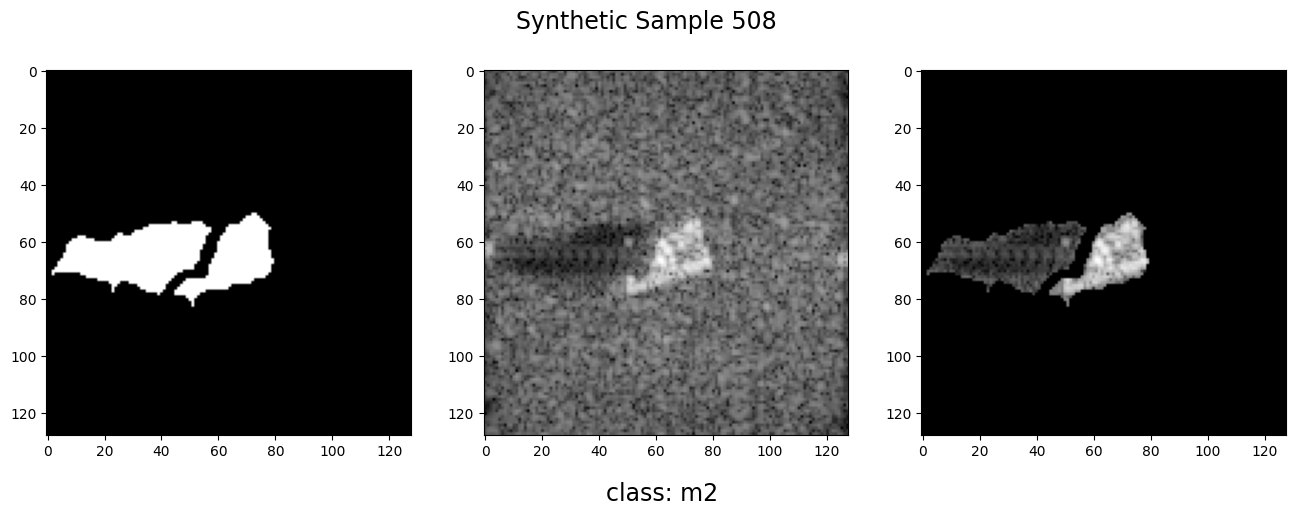

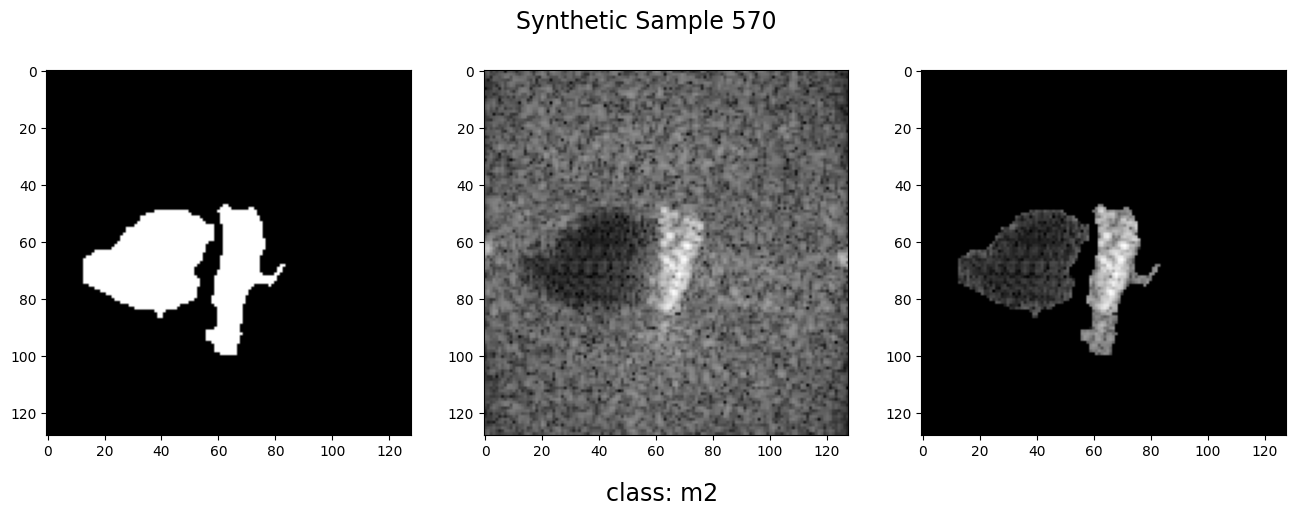

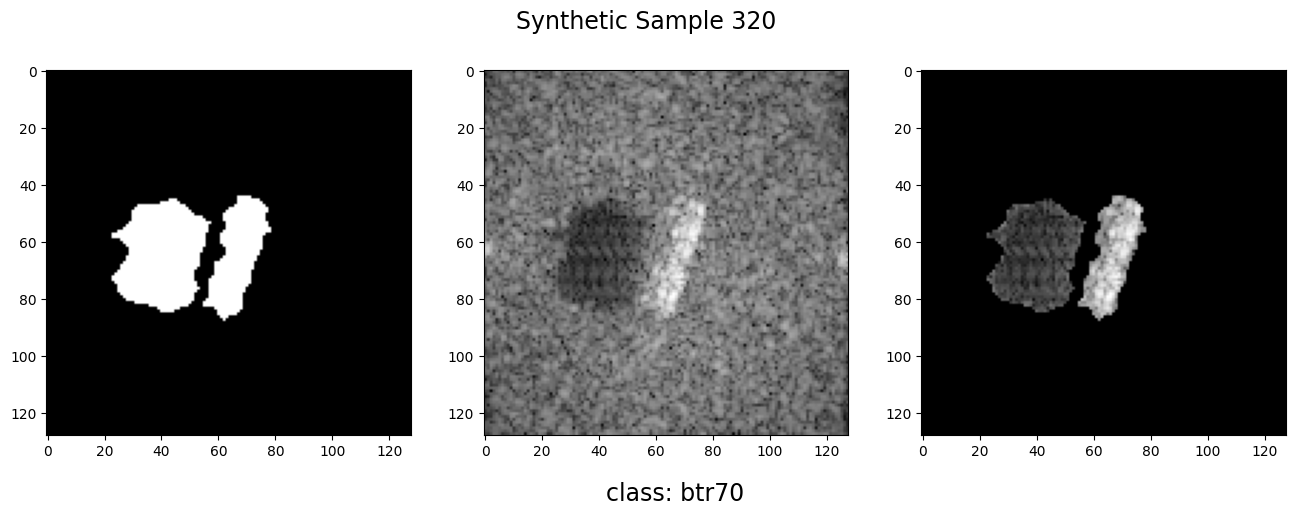

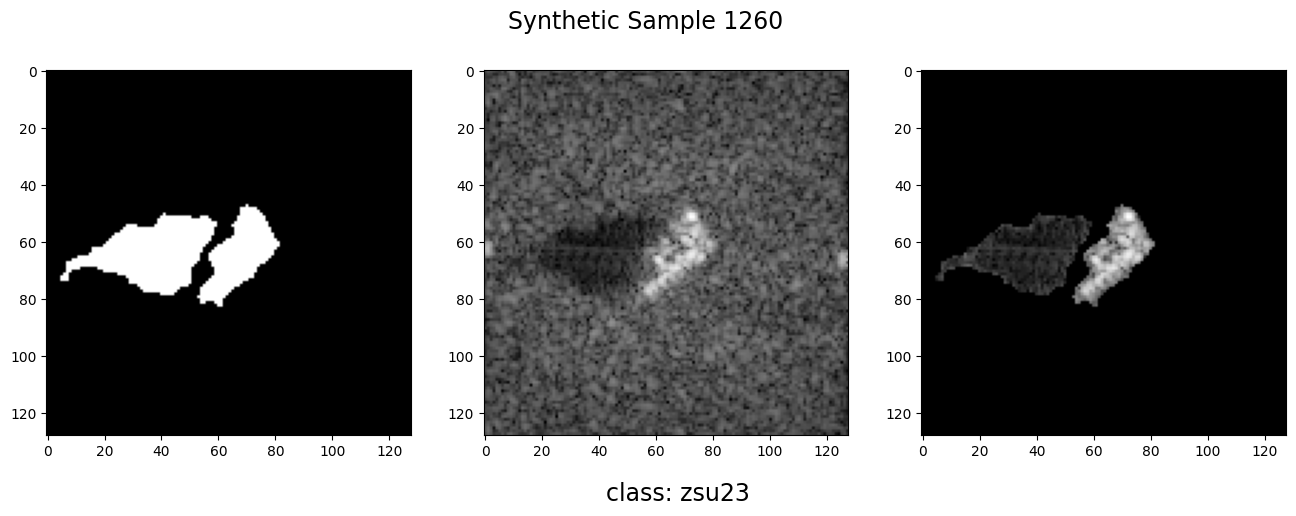

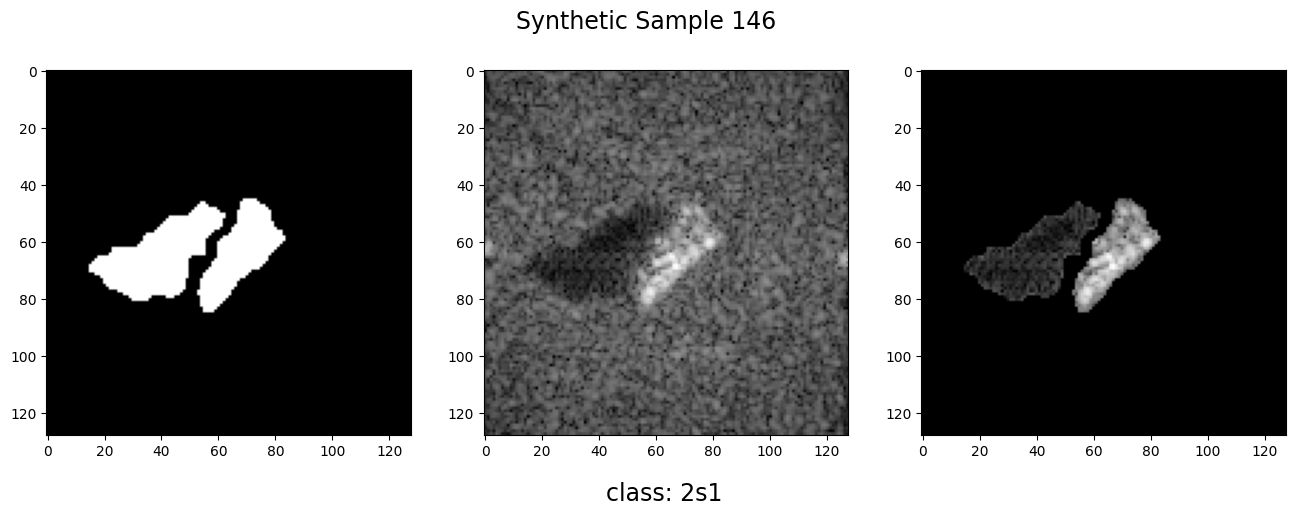

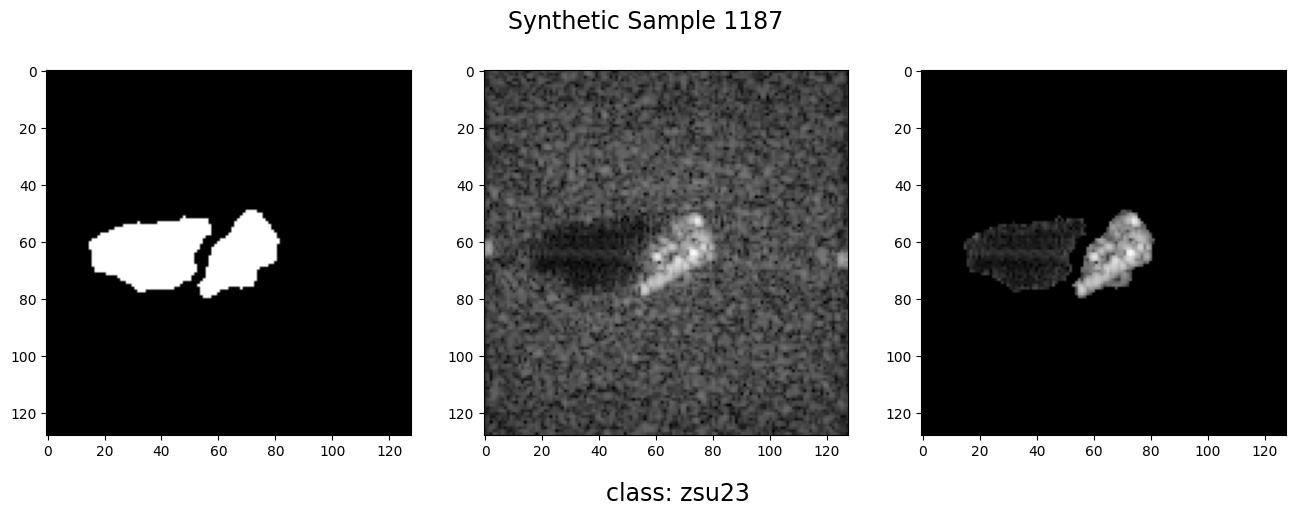

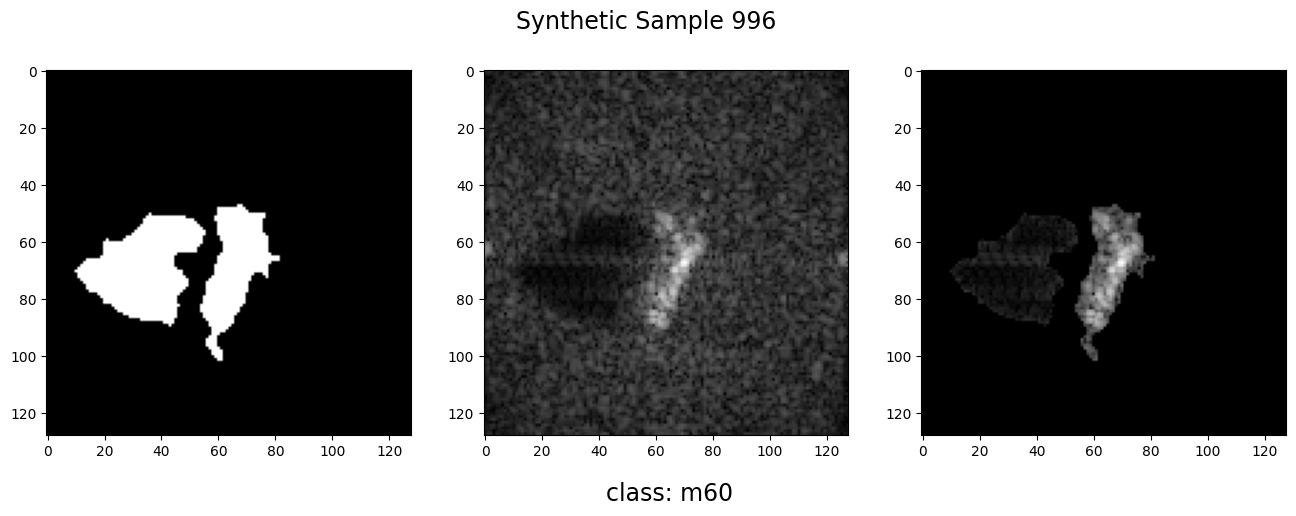

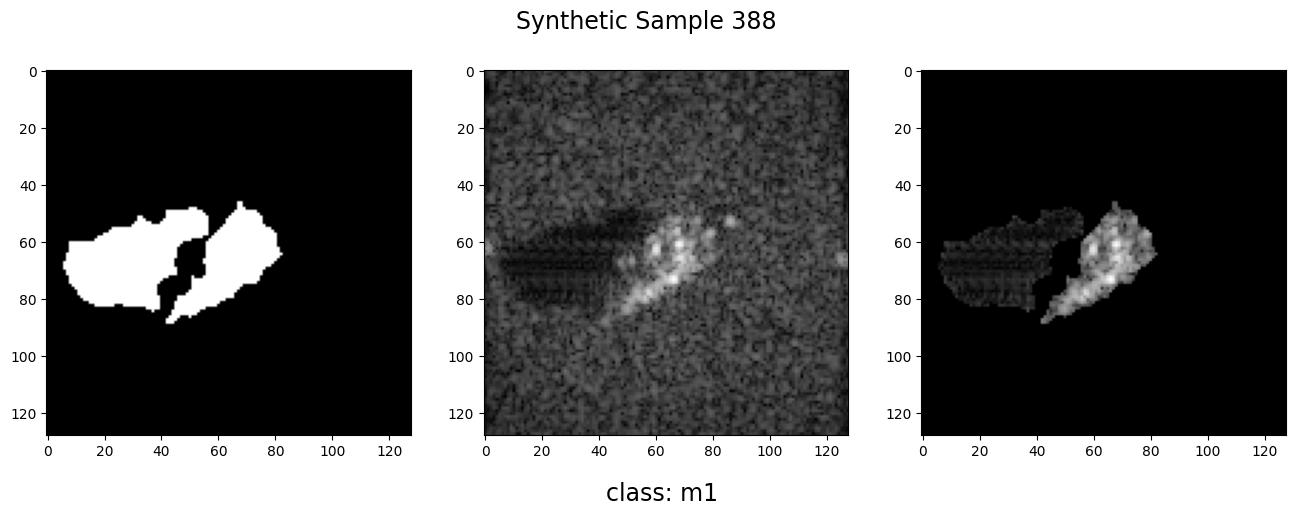

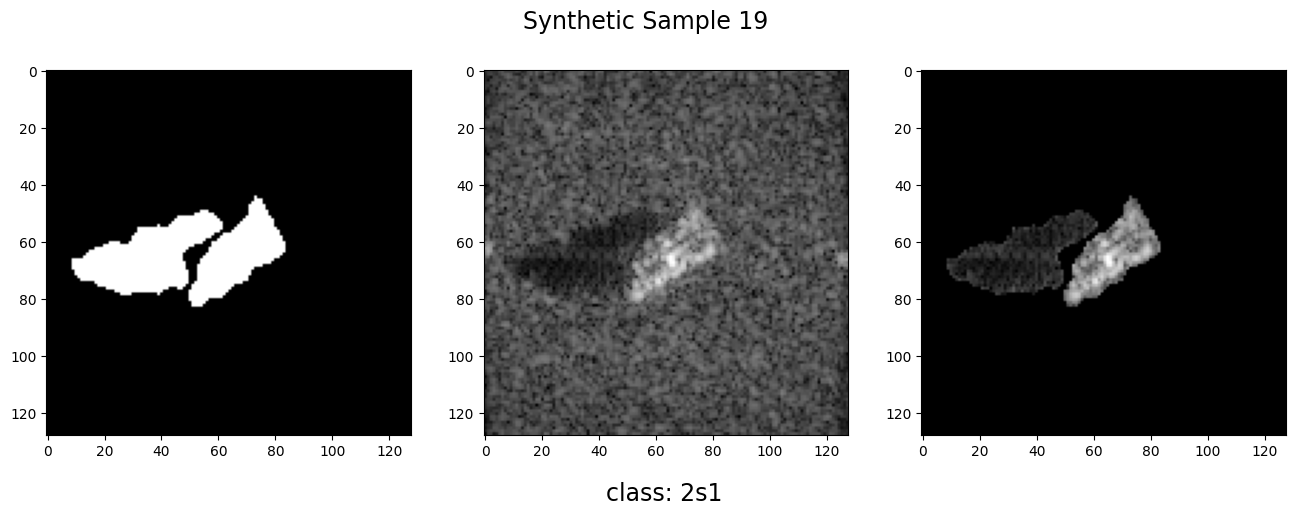

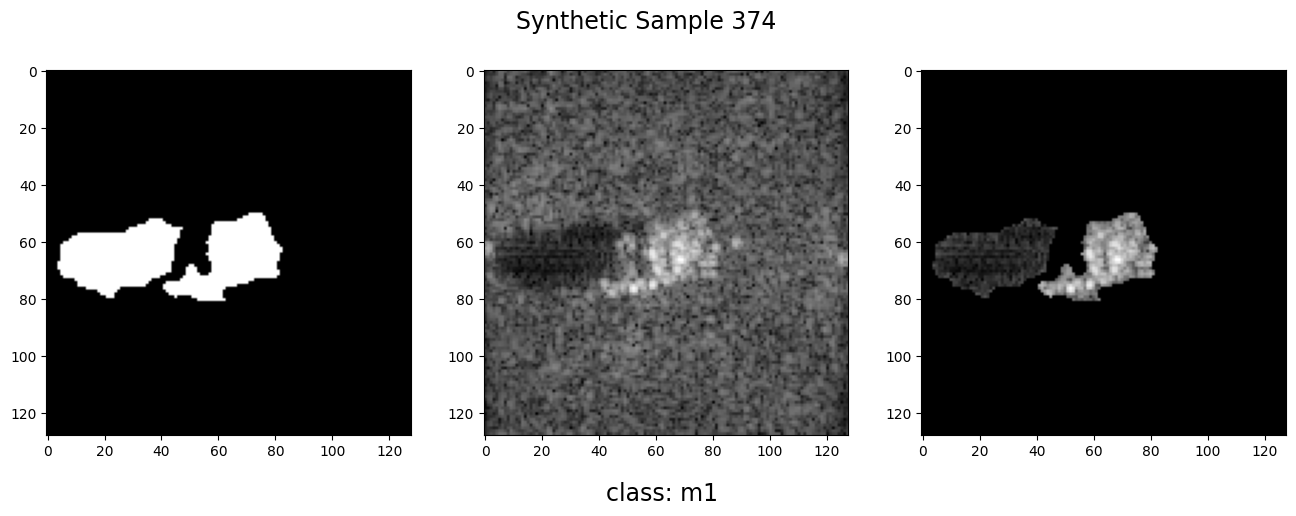

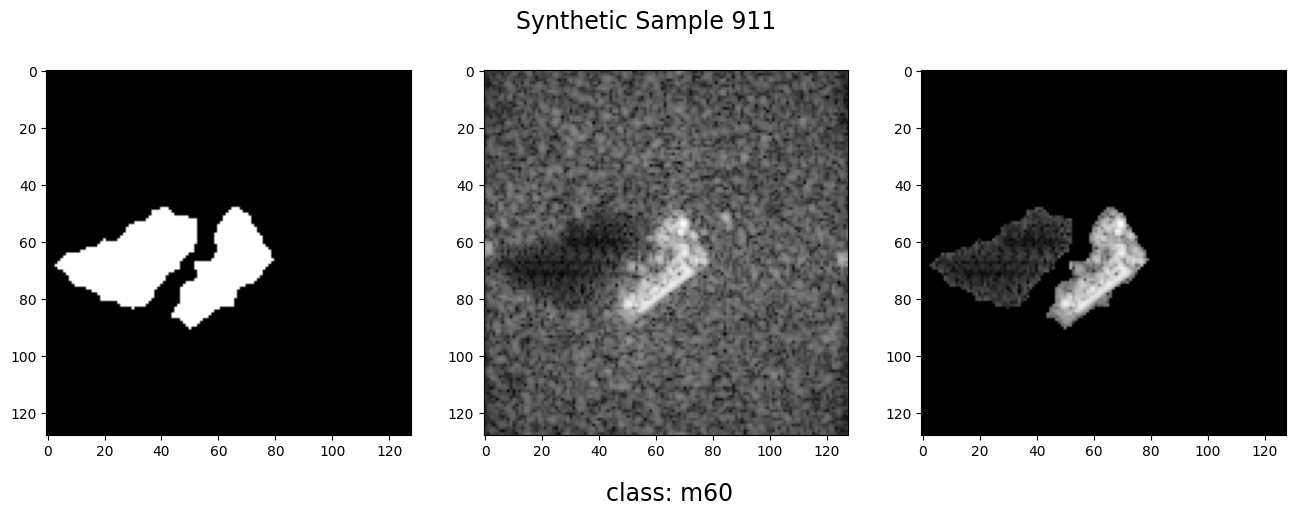

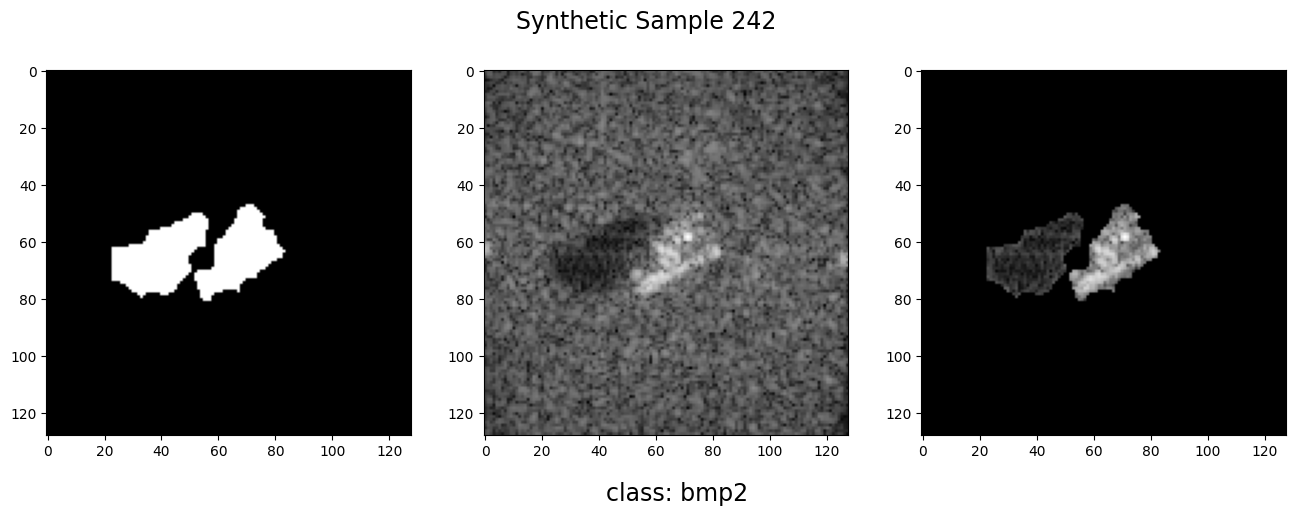

In [ ]:
for idx in np.random.choice(len(no_aug_synth_ds), size = 30, replace = False):
    img = no_aug_synth_ds[idx][0][0]
    t, s, c = choi_segmentation(img)
    
    fig = plt.figure(figsize = (16, 5))
    ax0 = fig.add_subplot(1, 3, 1)
    ax0.imshow(t*2 + s*1, cmap = "gray")
    ax1 = fig.add_subplot(1, 3, 2)
    ax1.imshow(img, cmap = "gray")
    ax2 = fig.add_subplot(1, 3, 3)
    ax2.imshow(img * (torch.tensor(t) + torch.tensor(s)), cmap = "gray", vmin = 0, vmax = 1)
    
    fig.suptitle(f"Synthetic Sample {idx}", size = 17)
    plt.figtext(0.475, -0.0025, f"class: {no_aug_synth_ds.classes[no_aug_synth_ds[idx][1]]}", size = 17)
    plt.show()

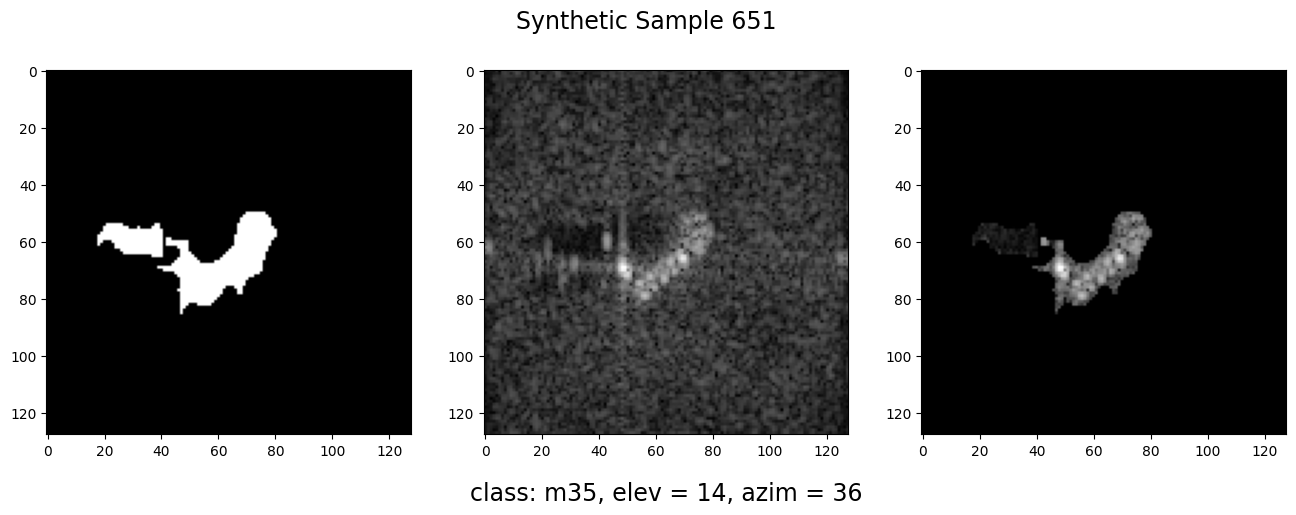

In [5]:
idx = 651
img = no_aug_synth_ds[idx][0][0]
t, s, c = choi_segmentation(img, high = 85, low = 30)

fig = plt.figure(figsize = (16, 5))
ax0 = fig.add_subplot(1, 3, 1)
ax0.imshow(t + s, cmap = "gray")
ax1 = fig.add_subplot(1, 3, 2)
ax1.imshow(img, cmap = "gray")
ax2 = fig.add_subplot(1, 3, 3)
ax2.imshow(img * (torch.tensor(t) + torch.tensor(s)), cmap = "gray", vmin = 0, vmax = 1)

path, _ = no_aug_synth_ds.samples[idx]
elev_re = re.search(r'elevDeg_(\d+)', path)
azim_re = re.search(r'azCenter_(\d+)', path)

elev = int(elev_re.group(1))
azim = int(azim_re.group(1))

fig.suptitle(f"Synthetic Sample {idx}", size = 17)
plt.figtext(0.39, -0.001, f"class: {no_aug_synth_ds.classes[no_aug_synth_ds[idx][1]]}, elev = {elev}, azim = {azim}", size = 17, transform = fig.transFigure)

plt.show()

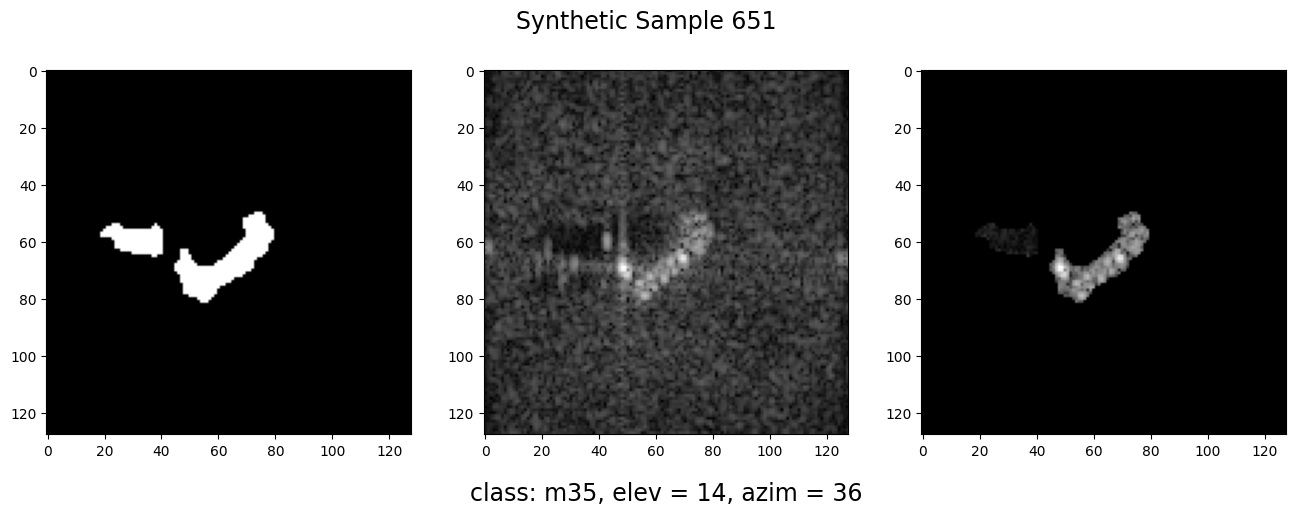

In [8]:
idx = 651
img = no_aug_synth_ds[idx][0][0]
t, s, c = choi_segmentation(img, high = 95, low = 25)

fig = plt.figure(figsize = (16, 5))
ax0 = fig.add_subplot(1, 3, 1)
ax0.imshow(t + s, cmap = "gray")
ax1 = fig.add_subplot(1, 3, 2)
ax1.imshow(img, cmap = "gray")
ax2 = fig.add_subplot(1, 3, 3)
ax2.imshow(img * (torch.tensor(t) + torch.tensor(s)), cmap = "gray", vmin = 0, vmax = 1)

path, _ = no_aug_synth_ds.samples[idx]
elev_re = re.search(r'elevDeg_(\d+)', path)
azim_re = re.search(r'azCenter_(\d+)', path)

elev = int(elev_re.group(1))
azim = int(azim_re.group(1))

fig.suptitle(f"Synthetic Sample {idx}", size = 17)
plt.figtext(0.39, -0.001, f"class: {no_aug_synth_ds.classes[no_aug_synth_ds[idx][1]]}, elev = {elev}, azim = {azim}", size = 17, transform = fig.transFigure)

plt.show()

In [66]:
seg_no_aug_synth_ds = synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose(
        [Magnitude(), 
         LogMapping(c = 1000.0), 
         MaskedAugmentation(augmentation = identity, fill = np.mean),
         NumpyToTensor3Channel()]
    ),
    loader = mat_file_loader
)

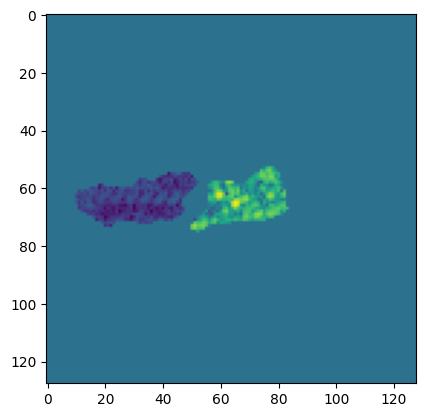

In [67]:
plt.imshow(seg_no_aug_synth_ds[0][0][0], vmin = 0, vmax = 1)

In [14]:
synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([Magnitude(), LogMapping(c = 1000.0), SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3), NumpyToTensor3Channel()]),
    loader = mat_file_loader
)
seg_synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose([
        Magnitude(), LogMapping(c = 1000.0), 
        MaskedAugmentation(
            SSRAugmentation(gmm_cache, alpha=0.6, beta=0.4, apply_prob=0.5, gaussian_noise = True, mu_s = 0.0, sigma_s = 0.3)), 
        NumpyToTensor3Channel()]),
    loader = mat_file_loader
)

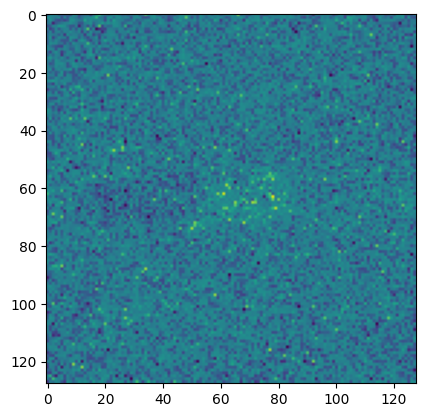

In [15]:
set_seed(42)
plt.imshow(synth_ds[0][0][0], vmin = 0, vmax = 1)
plt.show()

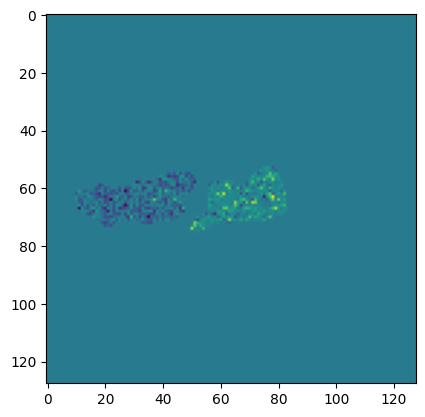

In [16]:
set_seed(42)
plt.imshow(seg_synth_ds[0][0][0], vmin = 0, vmax = 1)
plt.show()

In [62]:
class MaskedAugmentationSpeckleFill:
    """
    Computes Choi segmentation mask on the pre-augmentation image,
    applies augmentation, then masks the result to target+shadow only.
    
    Pipeline: log_mapped_img → compute mask → aug → apply mask
    
    Args:
        augmentation: SSRAugmentation, GaussianNoise, or any transform
                      that accepts (image, filepath) tuples
    """
    def __init__(self, augmentation, fill=np.mean, ray_sigma = 0.1):
        self.aug = augmentation
        self.fill = fill
        self.ray_sigma = ray_sigma

    def __call__(self, img_or_tuple):
        if isinstance(img_or_tuple, tuple):
            image, filepath = img_or_tuple
        else:
            # Can't segment without filepath context; passthrough
            return img_or_tuple

        # Step 1: compute mask on ORIGINAL log-mapped image
        M_target, M_shadow, _ = choi_segmentation(image, high = 95, low = 25)
        mask = (M_target + M_shadow)   # binary, {0, 1}

        # Step 2: apply augmentation
        aug_result = self.aug((image, filepath))
        aug_image = aug_result[0] if isinstance(aug_result, tuple) else aug_result
        fp = aug_result[1] if isinstance(aug_result, tuple) else filepath
        
        # Step 3: apply mask + fill using augmented image statistics
        if mask.any():
            target_shadow_pixels = aug_image[mask == 1]
            fill_val = self.fill(target_shadow_pixels) if callable(self.fill) else float(self.fill)
        else:
            fill_val = 0.0
        
        synthetic_clutter = np.random.rayleigh(self.ray_sigma, size=aug_image.shape).astype(np.float32)

        result = aug_image * mask + ((fill_val + synthetic_clutter)* (1 - mask))

        return (result.astype(np.float32), fp)

In [59]:
seg_speckle_synth_ds = synth_ds = DatasetFolderWithPath(
    os.path.join(data_workspace, "mat_files/synth"),
    extensions = (".mat"),
    transform = transforms.Compose(
        [Magnitude(), 
         LogMapping(c = 1000.0), 
         MaskedAugmentationSpeckleFill(augmentation = identity, fill = np.mean, ray_sigma = 0.1),
         NumpyToTensor3Channel()]
    ),
    loader = mat_file_loader
)

In [60]:
seg_speckle_synth_ds[idx][0][0].max()

tensor(1.)

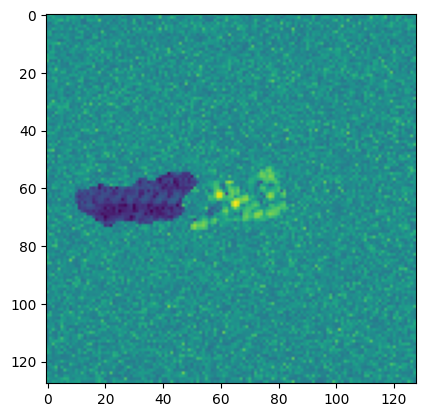

In [61]:
idx = 0 
plt.imshow(seg_speckle_synth_ds[idx][0][0])
plt.show()